<a href="https://colab.research.google.com/github/CayeRZ/cv-lab4-extra/blob/main/lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST GAN lab: realism, collapse, and recovery

**Your task:** recommend a diversity weight that recovers meaningful variety without seriously reducing image quality.

First inspect a GAN trained on all ten digits. Next watch the **same model** lose class coverage while continuing to produce recognizable digits. Finally compare four recovery experiments, each starting from the **same collapsed generator, discriminator, and optimizer states**.

$$\mathcal{L}_G = \mathcal{L}_{\mathrm{adversarial}} + \lambda_{\mathrm{div}}\mathcal{L}_{\mathrm{diversity}},$$
$$\mathcal{L}_{\mathrm{diversity}} = -\frac{\|G(\mathbf z_1)-G(\mathbf z_2)\|_1}{\|\mathbf z_1-\mathbf z_2\|_1+\epsilon}, \qquad
\lambda_{\mathrm{div}}\in\{0,\;0.1,\;0.5,\;1.0\}.$$

The implementation averages this ratio over independent pairs in a minibatch. A larger pixel-distance ratio is encouraged, but the regularizer does **not** know what a digit is. Your recommendation needs both measurements and visual evidence.

## 1. Environment and experiment controls

Select **Python (MNIST GAN Lab)**, then run from top to bottom. The local `.venv` includes PyTorch with CUDA, JupyterLab, and the plotting dependencies. The first run downloads MNIST and trains the models. Later runs reuse the saved checkpoints and regenerate the figures and metrics.

Set `REUSE_CHECKPOINTS=False` to retrain every stage, or `REUSE_RECOVERY=False` to rerun only the four recovery experiments. If you change training settings, use a fresh `output_dir` or turn off checkpoint reuse. Checkpoints with incompatible settings are rejected. CPU execution is supported but takes longer.

Training and evaluation helpers are in `gan_lab.py`; the exact regularizer and the experimental procedure are visible below. Keep that file beside the notebook.

In [ ]:
from pathlib import Path
from dataclasses import asdict
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from IPython.display import display
from gan_lab import (
    Config, configure, load_data, train_classifier, run_phase, evaluate,
    measure_images, metric_table, show_grid, show_histograms, show_comparison,
    show_losses, state_digest,
)
get_ipython().run_line_magic("matplotlib", "inline")

cfg = Config()
REUSE_CHECKPOINTS = True
REUSE_RECOVERY = True
DIVERSITY_WEIGHTS = (0.0, 0.1, 0.5, 1.0)
out = Path(cfg.output_dir)
out.mkdir(parents=True, exist_ok=True)
device = configure()
print(f"Python: {sys.executable}")
print(f"PyTorch: {torch.__version__} | Device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name())
else:
    print("CPU mode: cached checkpoints are recommended for the classroom.")
display(pd.Series(asdict(cfg), name="Configuration"))

Python: /home/mperez/Documents/last_lab/.venv/bin/python
PyTorch: 2.14.0+cu130 | Device: cuda
NVIDIA GeForce RTX 5060 Ti


seed                                           42
latent_dim                                    100
batch_size                                    128
learning_rate                              0.0002
classifier_epochs                               4
healthy_epochs                                 80
collapse_epochs                                20
recovery_epochs                                 8
collapse_digits                            (1, 7)
evaluation_samples                           5000
mode_threshold                               0.01
confidence_threshold                          0.9
data_root                                    data
output_dir              outputs/gan_mode_collapse
version                                         1
Name: Configuration, dtype: object

In [ ]:
x_train, y_train, x_test, y_test = load_data(cfg, device)
gan_images = x_train * 2 - 1  # GAN image range: [-1, 1]. Classifier range: [0, 1].

# CPU-created inputs are saved and reused for every evaluation and every grid.
# These seeds are independent of the training RNG.
evaluation_rng = torch.Generator().manual_seed(cfg.seed + 500)
fixed_noise = torch.randn(64, cfg.latent_dim, generator=evaluation_rng)
evaluation_noise = torch.randn(cfg.evaluation_samples, cfg.latent_dim, generator=evaluation_rng)
torch.save({"fixed_noise": fixed_noise, "evaluation_noise": evaluation_noise}, out / "evaluation_noise.pt")
print(f"Training images: {len(x_train):,}; held-out images: {len(x_test):,}")
print(f"Every quantitative GAN evaluation uses the same {len(evaluation_noise):,} latent vectors.")

Training images: 60,000; held-out images: 10,000
Every quantitative GAN evaluation uses the same 5,000 latent vectors.


## 2. Establish an independent evaluation reference

The classifier learns from real training images only. Its accuracy is checked on the held-out MNIST test set, and it is frozen before GAN evaluation. **No classifier loss, class labels, or confidence filtering is used to train the GAN.**

We report:

| Measurement | Definition and interpretation |
|---|---|
| Class coverage (`mode_count`) | Number of predicted classes with at least 1% of all generated samples. Rare classifier guesses do not automatically count as recovered modes. |
| Normalized class entropy | $-\sum_c \hat p(c)\log\hat p(c)/\log(10)$; 0 means one predicted class, 1 means uniform class frequencies. |
| Mean classifier confidence | Average maximum softmax probability, including uncertain samples. A proxy for recognizability, **not** proof of realism. |
| Feature-space diversity | Mean pairwise Euclidean distance among the first 1,000 unit-normalized penultimate-layer classifier features. Same classifier and scale for every model. |
| Within-class diversity | Per-digit feature distances using up to 200 predictions with confidence ≥ 0.90; a digit needs at least 20 such samples. The aggregate averages supported represented classes. Compare the per-digit results too, because the set of represented classes changes. |
| Confident coverage/diversity | Extra diagnostics using predictions with confidence ≥ 0.90. Coverage still divides by **all** generated samples. Small confident subsets can be misleading. |

Feature distances lie in $[0,2]$ after unit normalization; higher is not automatically better. Real MNIST provides context for natural class balance and writing variation. Its class counts also use classifier predictions, while classifier accuracy uses true labels.

Loaded classifier: outputs/gan_mode_collapse/evaluation_classifier.pt


Held-out classifier accuracy: 98.89%


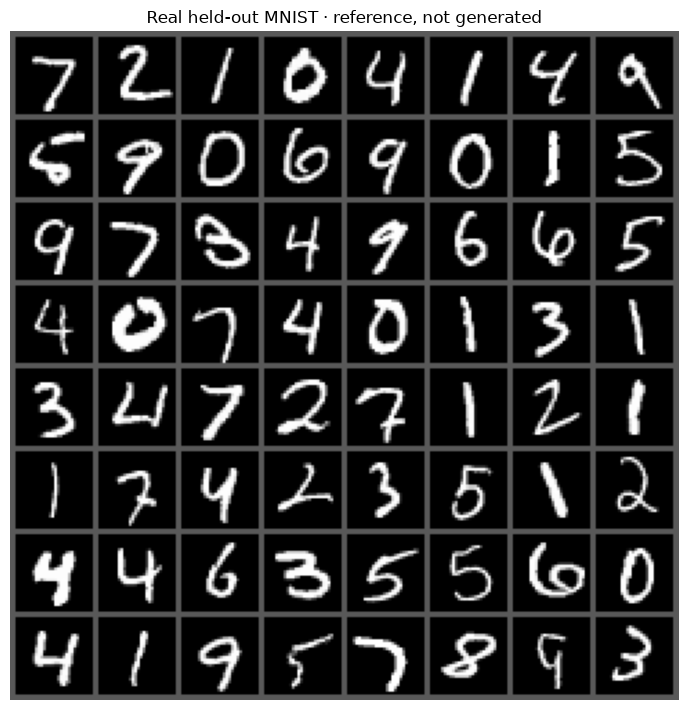

,mode_count,confident_mode_count,normalized_entropy,classifier_confidence,confident_fraction,feature_diversity,confident_feature_diversity,within_class_diversity
Configuration,,,,,,,,
Real MNIST,10,10,0.9988,0.9846,0.956,0.9396,0.9402,0.4994


In [ ]:
evaluation_classifier, classifier_test_accuracy = train_classifier(
    cfg, device, (x_train, y_train, x_test, y_test), reuse=REUSE_CHECKPOINTS,
)
print(f"Held-out classifier accuracy: {classifier_test_accuracy:.2%}")
real_evaluation = measure_images(x_test[:cfg.evaluation_samples], evaluation_classifier, cfg)
evaluations = {"Real MNIST": real_evaluation}
show_grid(x_test[:64].cpu(), "Real held-out MNIST · reference, not generated", out / "real_samples.png")
display(metric_table(evaluations).round(4))

## 3. The generator objective

The GAN is unconditional: $z\sim\mathcal N(0,I_{100})$. The discriminator emits logits. The non-saturating adversarial generator loss is $\operatorname{softplus}(-D(G(z)))$, equivalent to binary cross-entropy with target 1.

Both L1 norms below are **sums**, as in the stated formula. With 784 output pixels and 100 latent coordinates, using coordinate means instead would rescale the ratio by $100/784$ (apart from epsilon). Do not silently switch conventions: it changes the effective strength of every $\lambda_{\mathrm{div}}$.

During every update, two independent latent batches are generated, even for $\lambda=0$. The adversarial loss is averaged over both batches; the diversity loss is computed from corresponding pairs. All candidates therefore receive the same number of real and generated examples.

In [ ]:
def diversity_loss(fake_1, fake_2, z_1, z_2, epsilon=1e-6):
    image_l1 = (fake_1 - fake_2).abs().flatten(1).sum(dim=1)
    latent_l1 = (z_1 - z_2).abs().flatten(1).sum(dim=1)
    return -(image_l1 / (latent_l1 + epsilon)).mean()

# This exact function is passed into the training loop in every phase below.
# The generator update inside train_gan_epoch is:
# adversarial = F.softplus(-discriminator(torch.cat((fake_1, fake_2)))).mean()
# diversity = diversity_loss(fake_1, fake_2, z_1, z_2)
# loss_g = adversarial + diversity_weight * diversity
# loss_g.backward()
# optimizer_g.step()

## 4. Stage A — see the healthy GAN before collapse

Train on all 60,000 MNIST training images with the standard adversarial objective. This cell saves a complete healthy checkpoint **before** any biased training. Inspect the following unfiltered 8×8 grid, class histogram, and measurements before continuing.

The grid always uses the same 64 latent vectors. Images are not selected by digit or classifier confidence, and they are not real images substituted for generated output. Some imperfect samples can remain even in a useful GAN.

Loaded healthy: 80 epochs; checkpoint 69dae339dc16


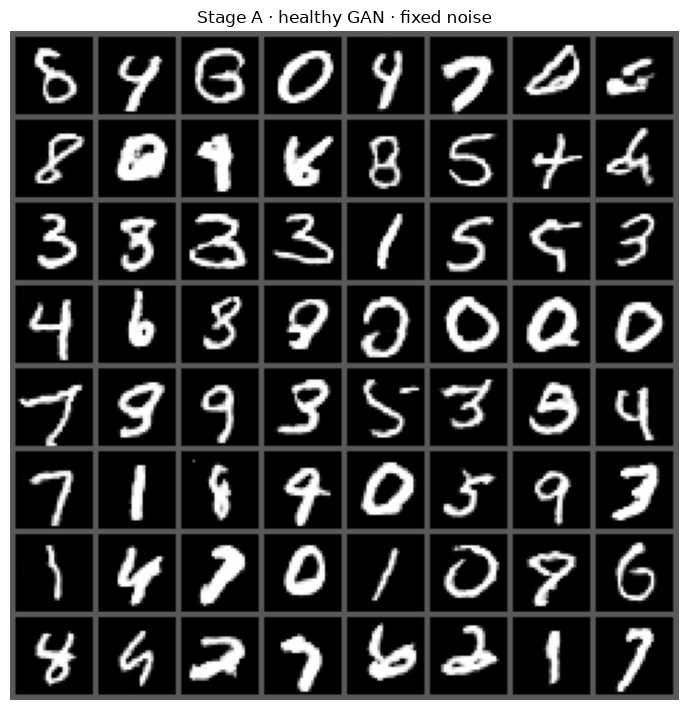

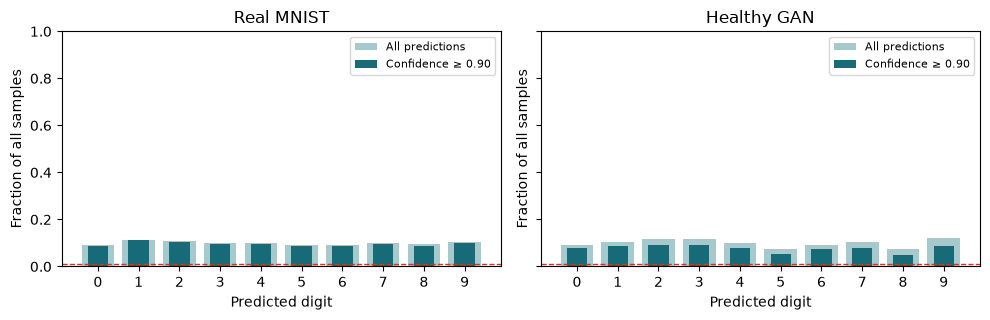

,mode_count,confident_mode_count,normalized_entropy,classifier_confidence,confident_fraction,feature_diversity,confident_feature_diversity,within_class_diversity
Configuration,,,,,,,,
Real MNIST,10,10,0.9988,0.9846,0.9560,0.9396,0.9402,0.4994
Healthy GAN,10,10,0.9939,0.9231,0.7722,0.9291,0.9379,0.5515


In [ ]:
healthy_generator, healthy_checkpoint, healthy_history = run_phase(
    cfg, device, gan_images, name="healthy", epochs=cfg.healthy_epochs,
    seed=cfg.seed, reuse=REUSE_CHECKPOINTS, loss_function=diversity_loss,
)
healthy_evaluation = evaluate(healthy_generator, evaluation_classifier, cfg, fixed_noise, evaluation_noise)
evaluations["Healthy GAN"] = healthy_evaluation
show_grid(healthy_evaluation["fixed_images"], "Stage A · healthy GAN · fixed noise", out / "healthy_samples.png")
show_histograms({"Real MNIST": real_evaluation, "Healthy GAN": healthy_evaluation}, cfg, out / "healthy_class_distribution.png")
display(metric_table(evaluations).round(4))
assert healthy_evaluation["mode_count"] >= 9, "Healthy stage has insufficient class coverage; inspect training."
assert healthy_evaluation["classifier_confidence"] >= 0.85, "Inspect healthy-stage sample quality before continuing."

**Pause and observe.** Which digits can you recognize? Are stroke thickness, slant, and shape varied? Identify any malformed samples. Keep these observations as your visual reference for recovery.

## 5. Stage B — induce recognizable class collapse

Continue adversarial training from the healthy generator **and discriminator**, now using only real digits **1 and 7**. Both optimizers are restored too. This deliberately changes the target distribution: the generator learns to discard the other eight classes while the discriminator still rewards realistic handwriting.

This is a **controlled class-collapse demonstration relative to full MNIST**, not a claim that ordinary full-data GAN training spontaneously collapsed. Labels are used only to construct the biased training subset. The model receives images, not labels. Within-class collapse is a separate empirical question; restricted digit coverage alone does not prove that every generated 1 or 7 is identical.

Biased training subset: 13,007 images of (1, 7)
Loaded collapsed: 20 epochs; checkpoint 89b538307d2a


Predicted mass on digits 1 and 7: 96.26%
Common recovery checkpoint SHA-256: 89b538307d2a7e96472de1cfa97b29b1f5556387df0f8c17e2187e6ced6eaf31


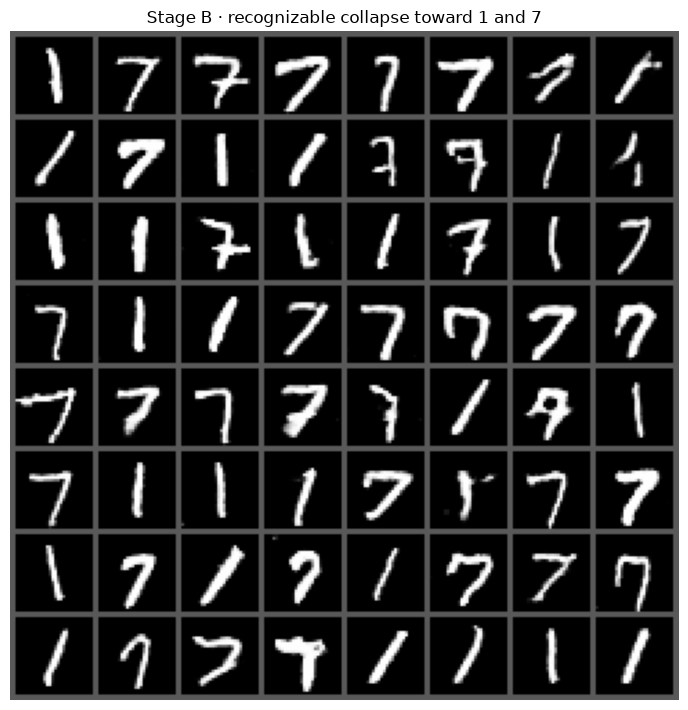

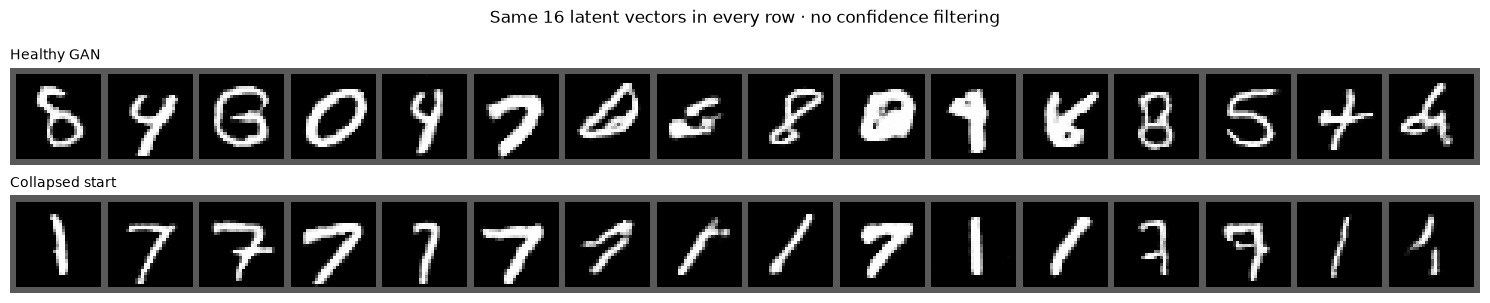

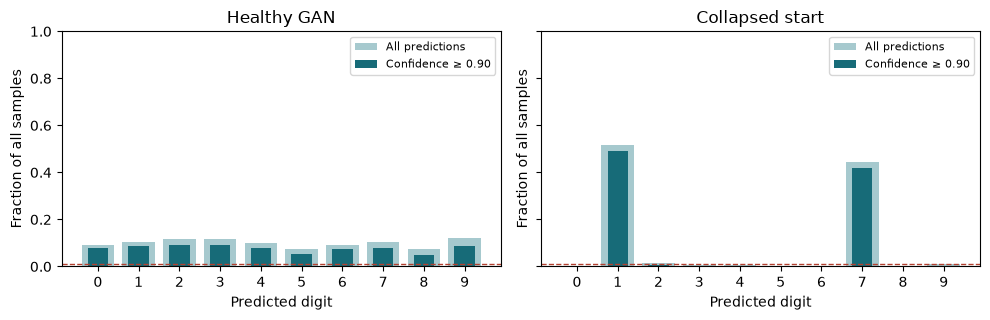

,mode_count,confident_mode_count,normalized_entropy,classifier_confidence,confident_fraction,feature_diversity,confident_feature_diversity,within_class_diversity
Configuration,,,,,,,,
Real MNIST,10,10,0.9988,0.9846,0.9560,0.9396,0.9402,0.4994
Healthy GAN,10,10,0.9939,0.9231,0.7722,0.9291,0.9379,0.5515
Collapsed start,4,2,0.3813,0.9715,0.9202,0.7163,0.7029,0.5106


In [ ]:
collapse_mask = torch.zeros_like(y_train, dtype=torch.bool)
for digit in cfg.collapse_digits:
    collapse_mask |= y_train == digit
print(f"Biased training subset: {int(collapse_mask.sum()):,} images of {cfg.collapse_digits}")
collapsed_generator, collapsed_checkpoint, collapse_history = run_phase(
    cfg, device, gan_images[collapse_mask], name="collapsed", epochs=cfg.collapse_epochs,
    seed=cfg.seed + 1, start=healthy_checkpoint, reuse=REUSE_CHECKPOINTS,
    loss_function=diversity_loss,
)
collapsed_digest = collapsed_checkpoint["state_digest"]
collapsed_evaluation = evaluate(collapsed_generator, evaluation_classifier, cfg, fixed_noise, evaluation_noise)
evaluations["Collapsed start"] = collapsed_evaluation
target_mass = float(collapsed_evaluation["class_frequencies"][list(cfg.collapse_digits)].sum())
print(f"Predicted mass on digits 1 and 7: {target_mass:.2%}")
print(f"Common recovery checkpoint SHA-256: {collapsed_digest}")
show_grid(collapsed_evaluation["fixed_images"], "Stage B · recognizable collapse toward 1 and 7", out / "collapsed_samples.png")
show_comparison({"Healthy GAN": healthy_evaluation, "Collapsed start": collapsed_evaluation}, out / "healthy_vs_collapsed.png")
show_histograms({"Healthy GAN": healthy_evaluation, "Collapsed start": collapsed_evaluation}, cfg, out / "collapsed_class_distribution.png")
display(metric_table(evaluations).round(4))
assert target_mass >= 0.85, "The intended collapsed modes are not dominant; inspect biased training."
assert collapsed_evaluation["mode_count"] <= 4, "This checkpoint is not sufficiently class-collapsed for the scenario."
assert collapsed_evaluation["classifier_confidence"] >= 0.85, "Collapse should preserve recognizability; inspect samples."

**Diagnosis checkpoint.** What evidence shows that the original GAN in the recovery scenario has mode collapse? Does the collapse occur between classes, within classes, or both? Use the images and class counts, not just the loss values.

## 6. Stage C — recover from the same collapsed checkpoint

Each candidate below restores the identical generator, discriminator, and both Adam optimizer states. The state digest is checked before training. All four candidates use the same real-data order, latent draws, architecture, learning rate, number of updates, and evaluation inputs. **Only the diversity weight differs.**

Full MNIST training data are restored for **every** candidate. Therefore $\lambda=0$ is an essential control: it measures recovery caused by renewed access to all ten digits and continued adversarial training. Credit the regularizer only for differences relative to that control. Larger weights are not guaranteed to improve coverage or quality monotonically.

In [ ]:
recovered_generators = {}
recovery_histories = {}
recovery_provenance = []
for weight in DIVERSITY_WEIGHTS:
    label = f"lambda={weight:g}"
    generator, checkpoint, history = run_phase(
        cfg, device, gan_images, name=f"recovery_lambda_{weight:g}",
        epochs=cfg.recovery_epochs, seed=cfg.seed + 100,
        start=collapsed_checkpoint, weight=weight,
        reuse=REUSE_CHECKPOINTS and REUSE_RECOVERY, loss_function=diversity_loss,
    )
    assert checkpoint["initial_digest"] == collapsed_digest
    recovered_generators[weight] = generator
    recovery_histories[label] = history
    evaluations[label] = evaluate(generator, evaluation_classifier, cfg, fixed_noise, evaluation_noise)
    recovery_provenance.append({
        "lambda": weight, "initial_digest": checkpoint["initial_digest"],
        "final_digest": checkpoint["state_digest"],
        "training_seconds": checkpoint["training_seconds"],
    })

# Confirm that none of the independent runs mutated the shared optimizer state.
assert state_digest({k: collapsed_checkpoint[k] for k in (
    "generator", "discriminator", "optimizer_g", "optimizer_d"
)}) == collapsed_digest
display(pd.DataFrame(recovery_provenance))
summary = metric_table(evaluations)
display(summary.round(4))

Loaded recovery_lambda_0: 8 epochs; checkpoint 45b3c82882cb


Loaded recovery_lambda_0.1: 8 epochs; checkpoint e8db675b1707


Loaded recovery_lambda_0.5: 8 epochs; checkpoint c610bb97192e


Loaded recovery_lambda_1: 8 epochs; checkpoint 156e58eebddd


,lambda,initial_digest,final_digest,training_seconds
0,0.0,89b538307d2a7e96472de1cfa97b29b1f5556387df0f8c...,45b3c82882cb9161b33463eb2e704ceeecc8eb7de59b3d...,20.673915
1,0.1,89b538307d2a7e96472de1cfa97b29b1f5556387df0f8c...,e8db675b17071f5a177a3553ed194ab6d40415684204e8...,20.691004
2,0.5,89b538307d2a7e96472de1cfa97b29b1f5556387df0f8c...,c610bb97192e434108bbdd86b6b43157d5eba9e94d5fdf...,20.678997
3,1.0,89b538307d2a7e96472de1cfa97b29b1f5556387df0f8c...,156e58eebddd95401d2ecbc466d6053126e7d0e6fa9e0d...,20.637863


,mode_count,confident_mode_count,normalized_entropy,classifier_confidence,confident_fraction,feature_diversity,confident_feature_diversity,within_class_diversity
Configuration,,,,,,,,
Real MNIST,10,10,0.9988,0.9846,0.9560,0.9396,0.9402,0.4994
Healthy GAN,10,10,0.9939,0.9231,0.7722,0.9291,0.9379,0.5515
Collapsed start,4,2,0.3813,0.9715,0.9202,0.7163,0.7029,0.5106
lambda=0,10,10,0.9963,0.9245,0.7734,0.9377,0.9462,0.5588
lambda=0.1,10,10,0.9966,0.9228,0.7746,0.9414,0.9509,0.5632
lambda=0.5,10,10,0.9854,0.9172,0.7534,0.9389,0.9495,0.5749
lambda=1,10,10,0.9730,0.9087,0.7348,0.9374,0.9475,0.5812


## 7. Look at the recovered digits

Every row in the first figure uses the same 16 latent vectors. The larger grids show the same 64 vectors for each candidate, including flawed images. A changed digit at a fixed latent position is expected because training changes the mapping; the comparison is for output quality and variation, not preservation of a particular digit identity.

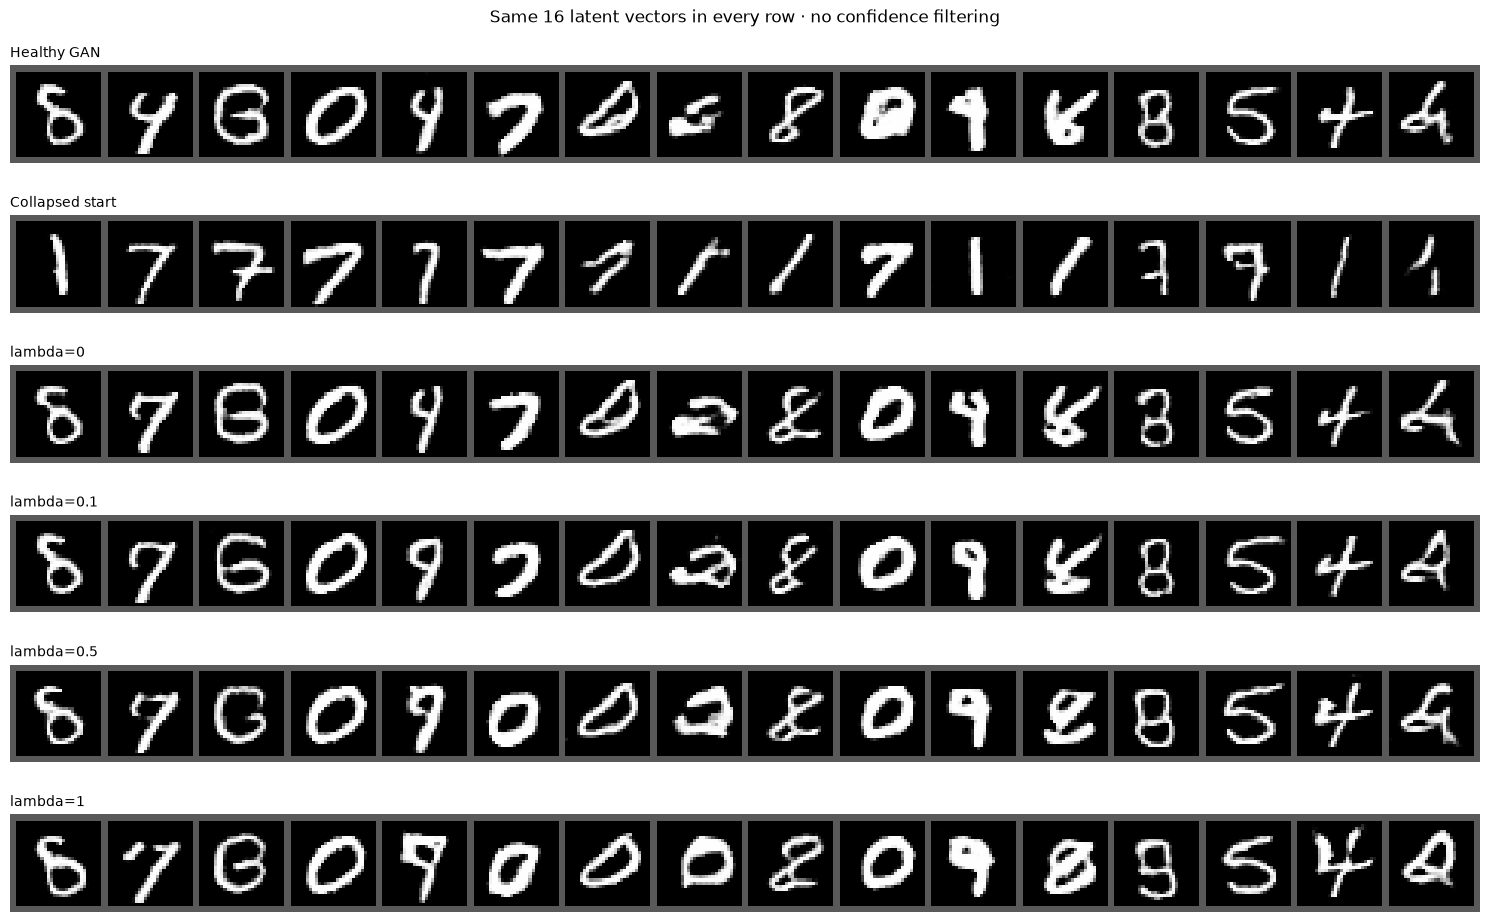

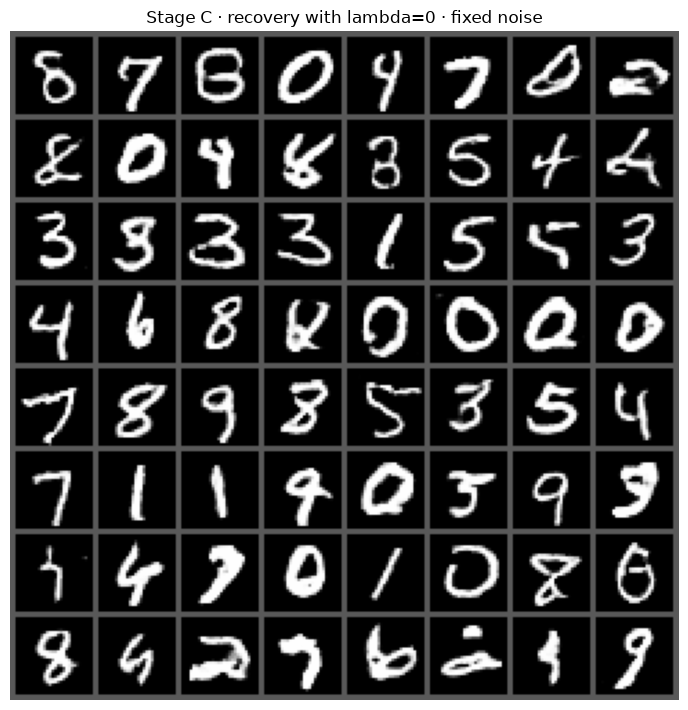

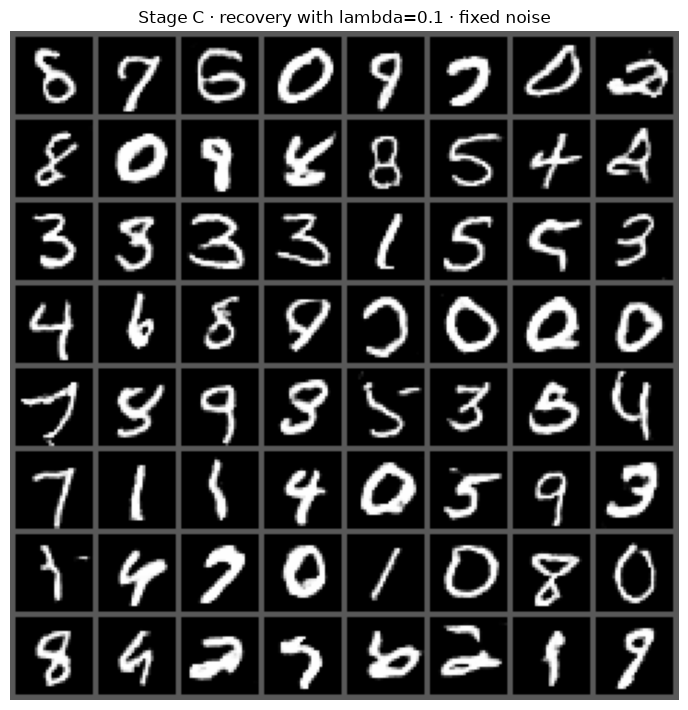

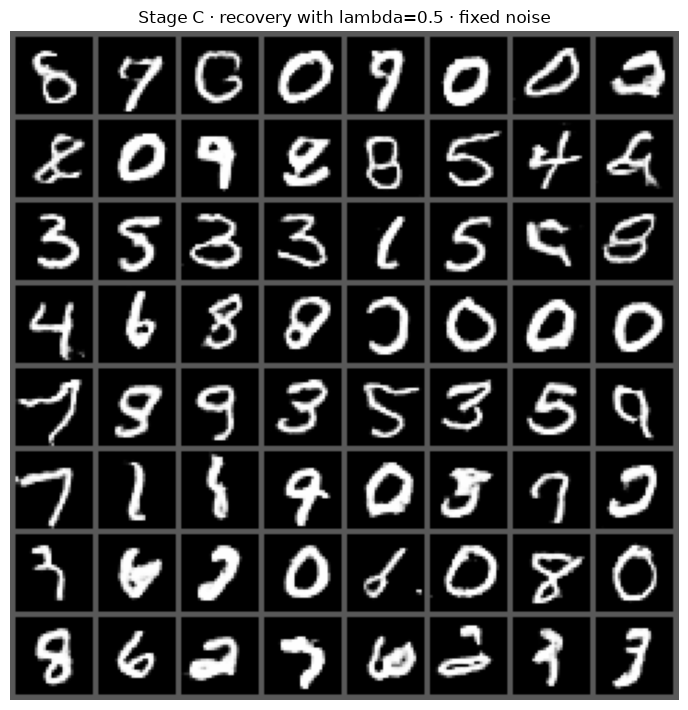

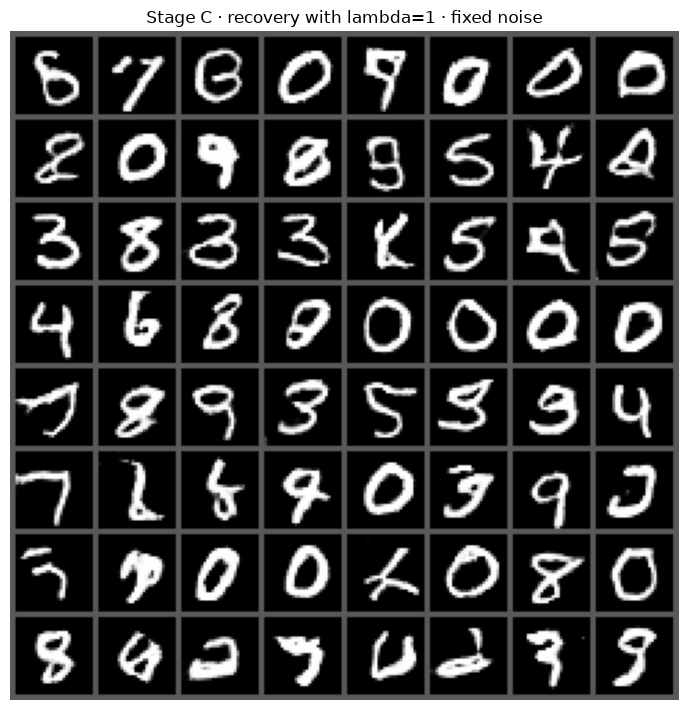

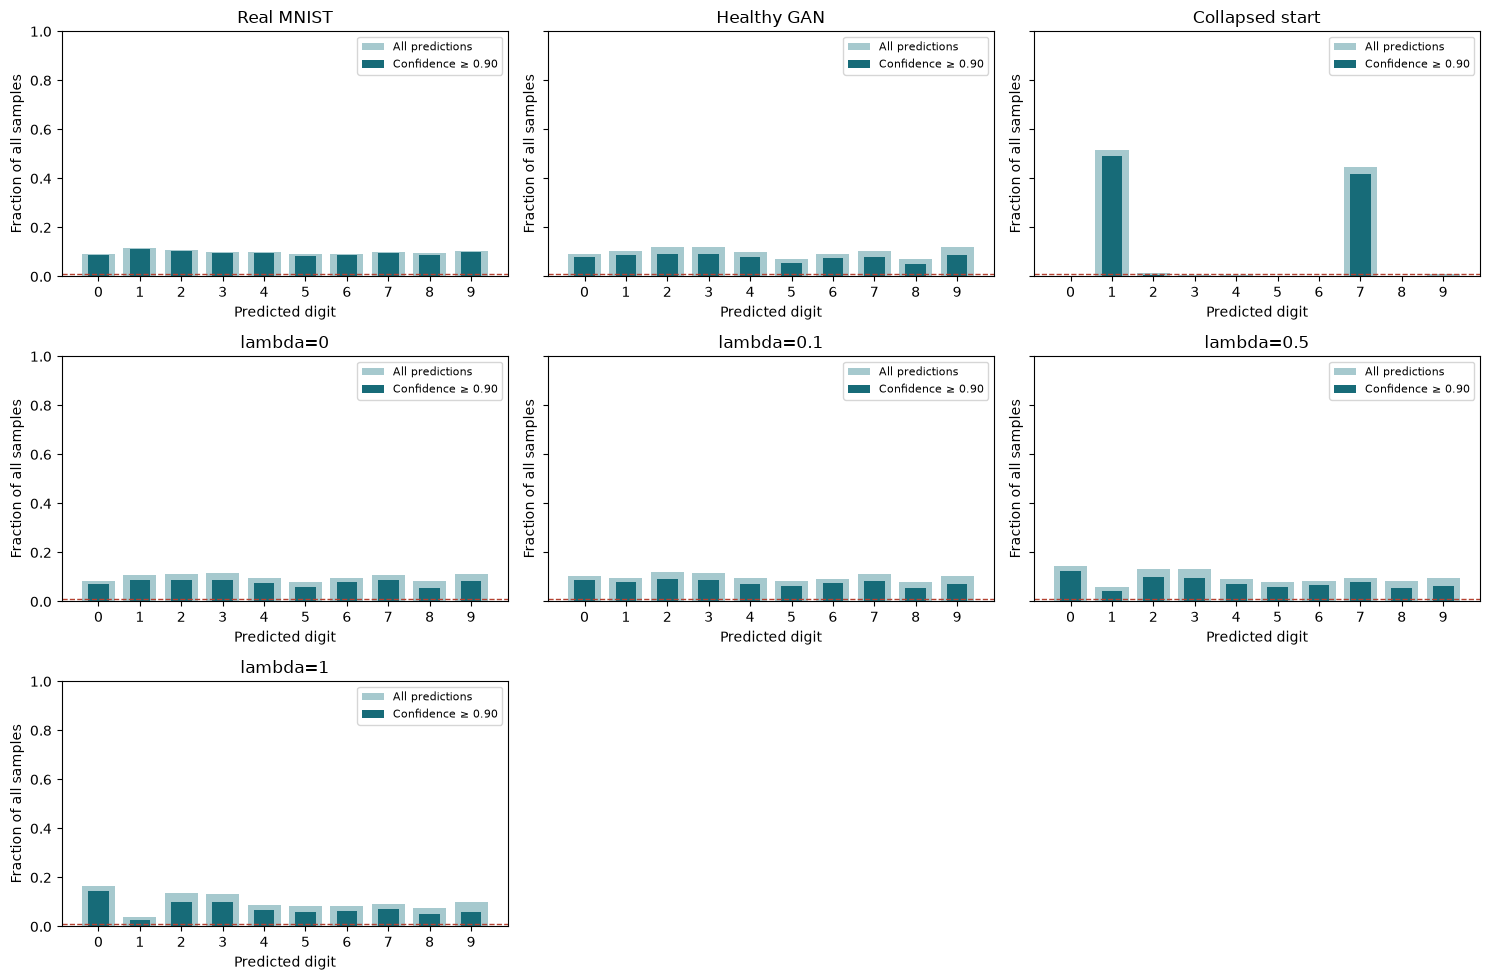

In [ ]:
generated_evaluations = {k: v for k, v in evaluations.items() if k != "Real MNIST"}
show_comparison(generated_evaluations, out / "recovery_samples.png")
for weight in DIVERSITY_WEIGHTS:
    show_grid(evaluations[f"lambda={weight:g}"]["fixed_images"],
              f"Stage C · recovery with lambda={weight:g} · fixed noise",
              out / f"samples_lambda_{weight:g}.png")
show_histograms(evaluations, cfg, out / "class_distributions.png")

## 8. Measure meaningful diversity and its quality cost

Compare each recovery candidate to the collapsed start, to the healthy GAN, to real MNIST, and especially to the $\lambda=0$ control. A high entropy based on malformed digits or confident classifier mistakes is weak evidence of recovery. Check whether confident coverage and the images support the raw class counts.

For the per-class heatmap, compare the same digit across configurations. Missing entries mean there are too few confident examples to estimate that class's diversity. Classifier features can miss differences in handwriting style and can respond unpredictably to distortions; they are one source of evidence.

,mode_count,confident_mode_count,normalized_entropy,classifier_confidence,confident_fraction,feature_diversity,confident_feature_diversity,within_class_diversity
Configuration,,,,,,,,
Real MNIST,10,10,0.9988,0.9846,0.9560,0.9396,0.9402,0.4994
Healthy GAN,10,10,0.9939,0.9231,0.7722,0.9291,0.9379,0.5515
Collapsed start,4,2,0.3813,0.9715,0.9202,0.7163,0.7029,0.5106
lambda=0,10,10,0.9963,0.9245,0.7734,0.9377,0.9462,0.5588
lambda=0.1,10,10,0.9966,0.9228,0.7746,0.9414,0.9509,0.5632
lambda=0.5,10,10,0.9854,0.9172,0.7534,0.9389,0.9495,0.5749
lambda=1,10,10,0.9730,0.9087,0.7348,0.9374,0.9475,0.5812


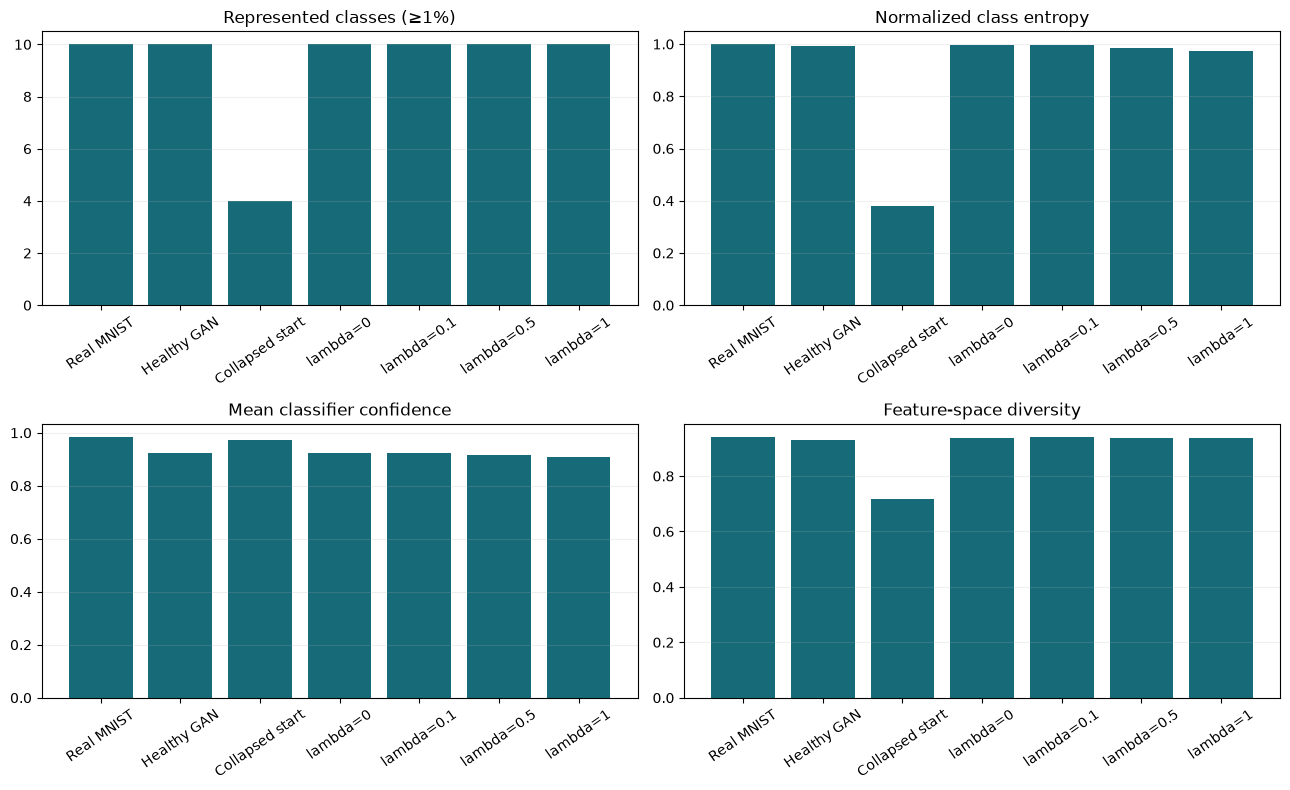

Predicted digit,0,1,2,3,4,5,6,7,8,9
Real MNIST,0.535,0.400,0.558,0.451,0.483,0.497,0.572,0.509,0.523,0.464
Healthy GAN,0.544,0.482,0.674,0.540,0.566,0.554,0.572,0.516,0.544,0.522
Collapsed start,NaN,0.437,0.614,NaN,NaN,NaN,NaN,0.481,NaN,NaN
lambda=0,0.560,0.487,0.685,0.548,0.566,0.586,0.573,0.518,0.552,0.514
lambda=0.1,0.561,0.511,0.683,0.537,0.563,0.592,0.588,0.515,0.564,0.519
lambda=0.5,0.524,0.561,0.689,0.555,0.579,0.587,0.594,0.535,0.584,0.541
lambda=1,0.502,0.618,0.684,0.546,0.598,0.572,0.592,0.551,0.603,0.546


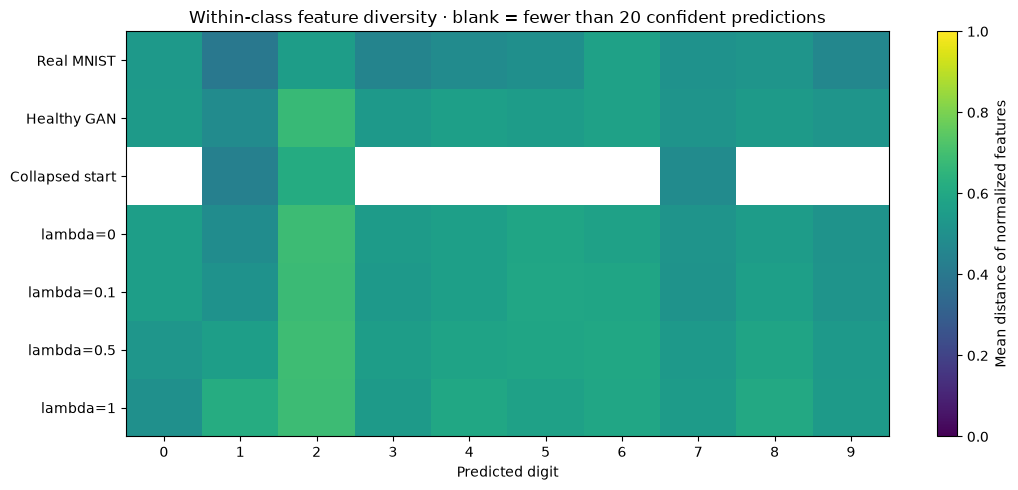

In [ ]:
summary.to_csv(out / "results.csv")
display(summary.round(4))
columns = ["mode_count", "normalized_entropy", "classifier_confidence", "feature_diversity"]
titles = ["Represented classes (≥1%)", "Normalized class entropy", "Mean classifier confidence", "Feature-space diversity"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, column, title in zip(axes.flat, columns, titles):
    ax.bar(summary.index, summary[column], color="#176b78")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(out / "recovery_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

within = pd.DataFrame({name: ev["per_class_diversity"] for name, ev in evaluations.items()}, index=range(10)).T
within.columns.name = "Predicted digit"
within.to_csv(out / "within_class_diversity.csv")
display(within.round(3))
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(within.to_numpy(), vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set(xticks=range(10), xlabel="Predicted digit", yticks=range(len(within)), yticklabels=within.index,
       title="Within-class feature diversity · blank = fewer than 20 confident predictions")
fig.colorbar(im, ax=ax, label="Mean distance of normalized features")
fig.tight_layout()
fig.savefig(out / "within_class_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

### Within-class visual inspection

These additional galleries show the **first** eight images assigned to each predicted digit, in evaluation order. They are grouped by predicted class only, not ranked by confidence. Missing slots stay blank. The unfiltered grids above remain the primary quality evidence. Watch for repeated shapes, broken strokes, speckled backgrounds, and ambiguous digits.

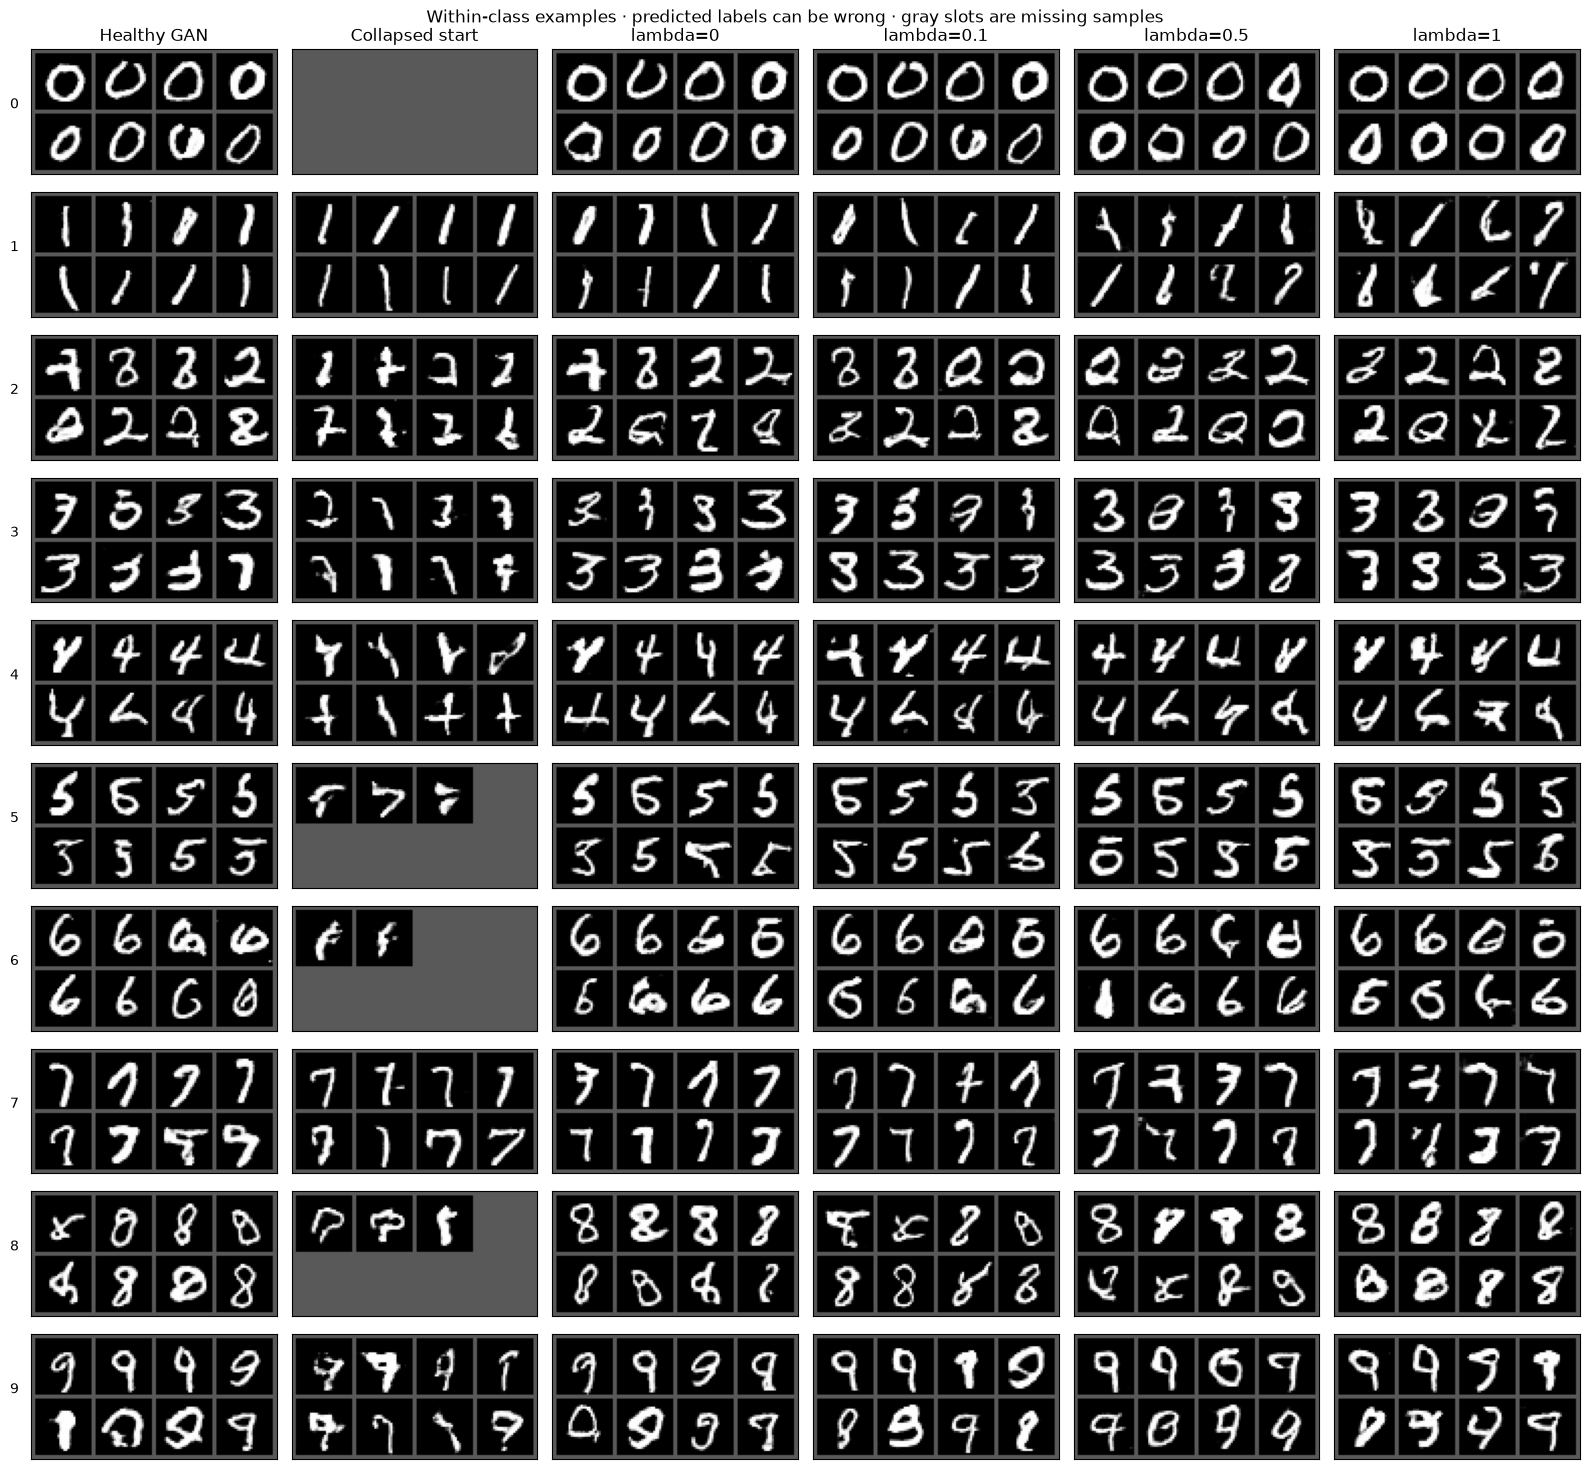

In [ ]:
fig, axes = plt.subplots(10, len(generated_evaluations), figsize=(16, 15))
from torchvision.utils import make_grid
for col, (name, ev) in enumerate(generated_evaluations.items()):
    for digit in range(10):
        ax = axes[digit, col]
        samples = ev["images"][ev["predictions"] == digit][:8]
        slots = torch.full((8, 1, 28, 28), 0.35)
        slots[:len(samples)] = samples
        grid = make_grid(slots, nrow=4, padding=2, pad_value=0.35)
        ax.imshow(grid.permute(1, 2, 0))
        ax.set(xticks=[], yticks=[])
        if col == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=12)
        if digit == 0:
            ax.set_title(name)
fig.suptitle("Within-class examples · predicted labels can be wrong · gray slots are missing samples")
fig.tight_layout()
fig.savefig(out / "within_class_samples.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 9. Loss curves: useful, but insufficient

The first plot records healthy training and the induced collapse as separate phases. The second compares recovery runs and separates the generator's adversarial and diversity components.

The total generator objective can be negative because the diversity term is negative. Total losses with different $\lambda$ values optimize different objectives, so their absolute values are not directly comparable quality scores. GAN losses do not measure class coverage, within-class variation, or how a human perceives a digit.

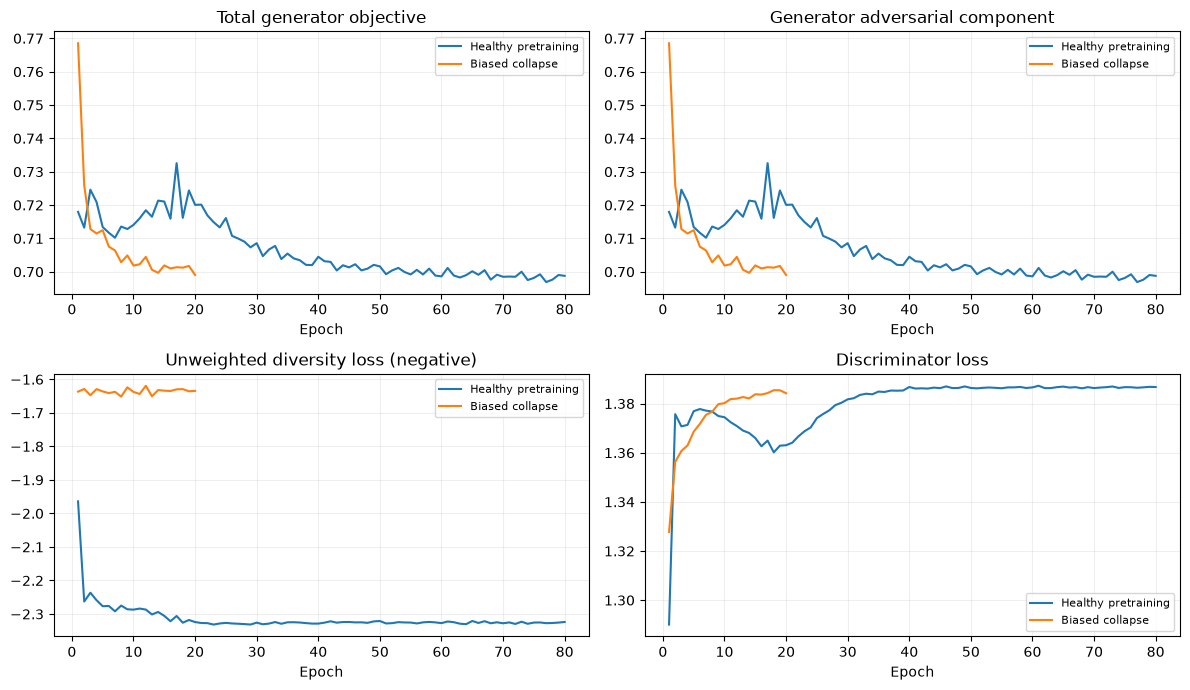

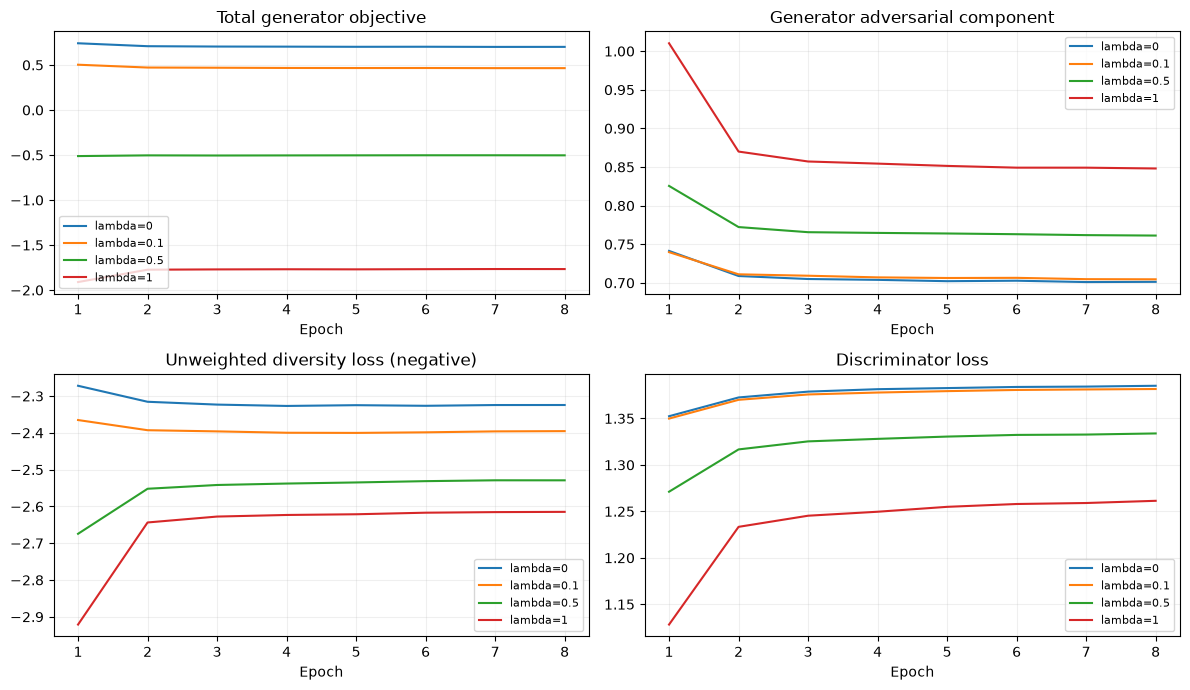

In [ ]:
show_losses({"Healthy pretraining": healthy_history, "Biased collapse": collapse_history}, out / "preparation_training.png")
show_losses(recovery_histories, out / "recovery_training.png")
for name, history in recovery_histories.items():
    history.to_csv(out / f"history_{name.replace('=', '_')}.csv", index=False)

## 10. Interpretation questions

1. What evidence shows that the original GAN has mode collapse?
2. Does the collapse occur between classes, within classes, or both?
3. How does increasing $\lambda_{\mathrm{div}}$ affect class coverage?
4. Which value produces the greatest meaningful diversity?
5. Does greater diversity reduce sample quality?
6. Are the samples meaningfully different, or do they simply contain more noise?
7. Why are generator and discriminator losses insufficient for detecting mode collapse?
8. Which value provides the best balance between realism and diversity?
9. What limitation does the selected configuration still have?

In question 8, state what you regard as a serious quality reduction and support that judgment with both the images and confidence measurements. Do not assume the strongest regularizer must win. A single seed and training budget do not establish a universal best weight; restoring the full data distribution is also part of this intervention.

## 11. Final decision — learner response

**I recommend $\lambda_{\mathrm{div}}=\underline{\hspace{1.5cm}}$ because...**

Complete all six evidence statements:

- **Class coverage:** ___ classes at the 1% threshold, compared with ___ at the collapsed start and ___ for $\lambda=0$.
- **Class entropy:** ___; this indicates ___ about class balance.
- **Classifier confidence:** ___, versus ___ for the healthy GAN; the corresponding visual quality is ___ .
- **Feature-space diversity:** ___ overall and ___ within classes; these measurements suggest ___ .
- **Visual sample quality:** cite specific samples/digits and describe realism, writing variation, and any noise or distorted strokes.
- **At least one limitation:** ___; explain how it limits the recommendation and what you would check next.

Your final choice belongs to you. The notebook does not silently optimize a composite score or select only attractive samples.

In [ ]:
# Optional: after completing the reasoning above, put your choice here and rerun.
# Leave None to run the complete notebook without supplying a learner answer.
SELECTED_LAMBDA = None
if SELECTED_LAMBDA is not None:
    assert SELECTED_LAMBDA in DIVERSITY_WEIGHTS
    label = f"lambda={SELECTED_LAMBDA:g}"
    display(summary.loc[list(dict.fromkeys(["Healthy GAN", "Collapsed start", "lambda=0", label]))].round(4))
    show_grid(evaluations[label]["fixed_images"], f"My selected recovery: {label}", out / "selected_samples.png")
else:
    print("Complete the evidence-based recommendation above, then optionally set SELECTED_LAMBDA.")

Complete the evidence-based recommendation above, then optionally set SELECTED_LAMBDA.


In [ ]:
configuration = {
    **asdict(cfg), "diversity_weights": DIVERSITY_WEIGHTS, "device": str(device),
    "torch_version": str(torch.__version__), "classifier_test_accuracy": classifier_test_accuracy,
    "collapsed_checkpoint_digest": collapsed_digest,
    "recovery_provenance": recovery_provenance,
    "loss_convention": "batch mean of per-pair L1 SUM ratios; images [-1,1], z ~ N(0,I_100)",
    "selected_lambda": SELECTED_LAMBDA,
}
(out / "configuration.json").write_text(json.dumps(configuration, indent=2))
summary.to_latex(out / "summary_table.tex", float_format="%.4f")
torch.save(evaluations, out / "evaluations.pt")
print(f"Saved checkpoints, fixed noise, PNG figures, CSV metrics, histories, and configuration to {out.resolve()}")

Saved checkpoints, fixed noise, PNG figures, CSV metrics, histories, and configuration to /home/mperez/Documents/last_lab/outputs/gan_mode_collapse


## References and reproducibility

The distance-ratio regularizer is inspired by [Mao et al., *Mode Seeking Generative Adversarial Networks for Diverse Image Synthesis*, CVPR 2019](https://arxiv.org/abs/1903.05628). Their paper studies conditional generation; this notebook applies the stated ratio to an unconditional MNIST classroom experiment. The induced biased-data failure and recovery protocol are specific to this lab.

See the [official PyTorch installation guide](https://pytorch.org/get-started/locally/) for platform-specific setup. `requirements.txt` records the tested direct dependencies, and `requirements-lock.txt` records the complete local environment. The saved checkpoint digests establish the common starting state; fixed seeds do not guarantee identical floating-point trajectories across different GPUs or PyTorch versions.

All report files are under `outputs/gan_mode_collapse/`. `lab_new.original.ipynb` preserves the original notebook. To repeat only recovery, set `REUSE_RECOVERY=False`; to repeat the complete training process, set `REUSE_CHECKPOINTS=False`. Inspect the images again after retraining.